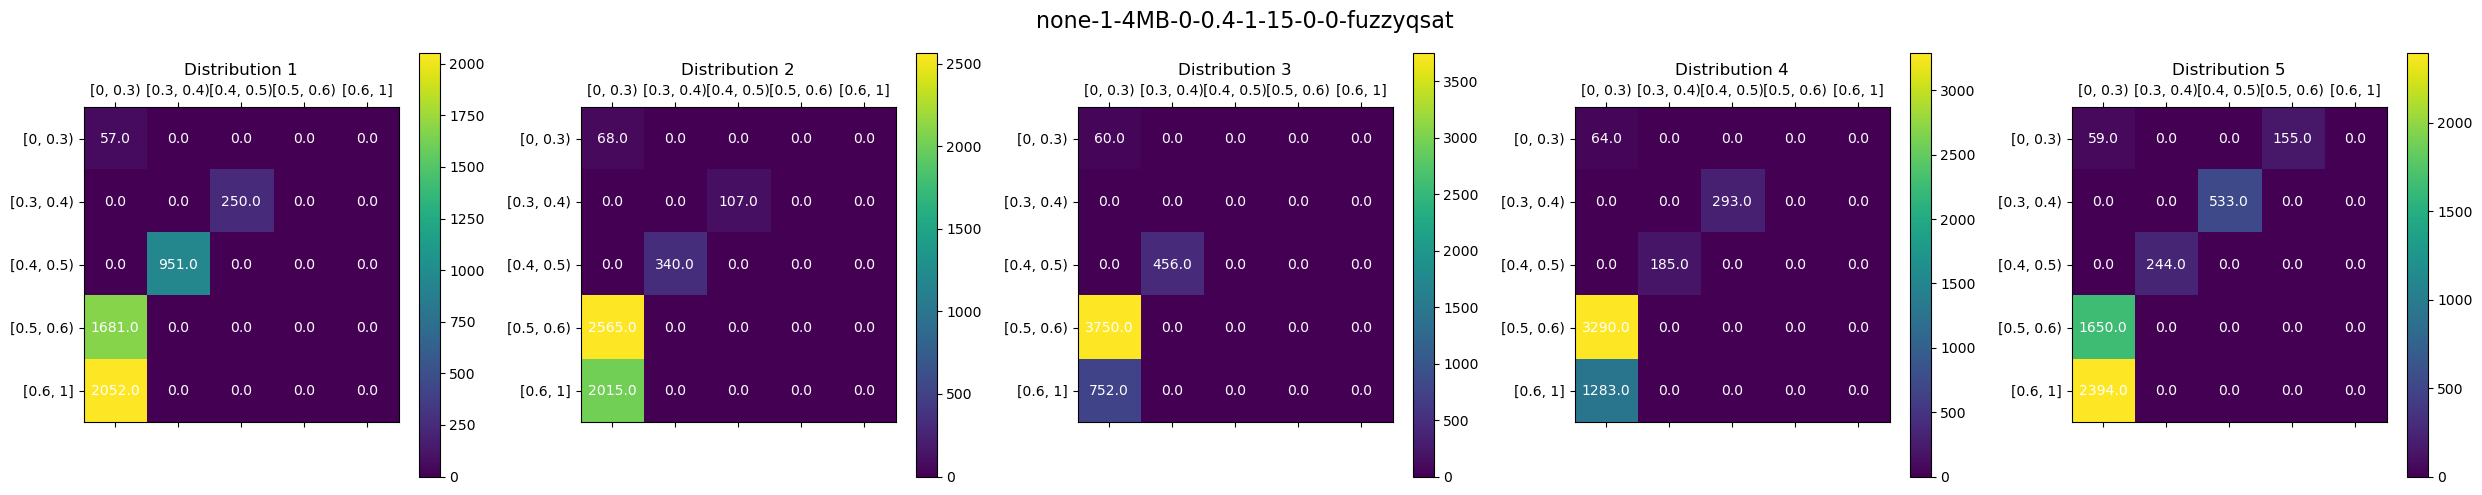

In [5]:
import csv
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters for the file path
sch = 'fuzzyqsat'
mdl = 'none'
clt = 1
size = '4MB'
bwd = 1
owd = 15
var = 0
los = 0

# Initialize an empty list to hold matrices
matrices = []

# Read the file and process it
file_path = f'../output/{mdl}-{clt}-{size}-0-0.4-{bwd}-{owd}-{var}-{los}-{sch}-state_dis.csv'

plt.rcParams.update({'font.size': 10})

# Read the file and process it
with open(file_path, 'r') as file:
    reader = csv.reader(file)
    matrix = []
    for i, row in enumerate(reader):
        if i % 5 == 0 and i != 0:
            matrices.append(matrix)
            matrix = []
        matrix.append([float(value) for value in row])
    if matrix:
        matrices.append(matrix)

# Create heatmaps for each 5x5 matrix using matplotlib
# num_matrices = len(matrices)-26
num_matrices = 5
fig, axes = plt.subplots(1, num_matrices, figsize=(num_matrices * 5, 5), squeeze=False)

# Labels for rows and columns
row_labels = ["[0, 0.3)", "[0.3, 0.4)", "[0.4, 0.5)", "[0.5, 0.6)", "[0.6, 1]"]
col_labels = ["[0, 0.3)", "[0.3, 0.4)", "[0.4, 0.5)", "[0.5, 0.6)", "[0.6, 1]"]

for i, ax in enumerate(axes.flatten()):
    cax = ax.matshow(matrices[i], cmap='viridis')
    for (j, k), val in np.ndenumerate(matrices[i]):
        ax.text(k, j, f'{val:.1f}', ha='center', va='center', color='white')

    # Set row and column labels
    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels(col_labels)
    ax.set_yticklabels(row_labels)

   # Rotate the x labels for better readability
    # plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    ax.set_title(f'Distribution {i+1}')
    fig.colorbar(cax, ax=ax)
# Set the title for the entire plot
plt.suptitle(f'{mdl}-{clt}-{size}-0-0.4-{bwd}-{owd}-{var}-{los}-{sch}', fontsize=16)

plt.tight_layout()
plt.show()

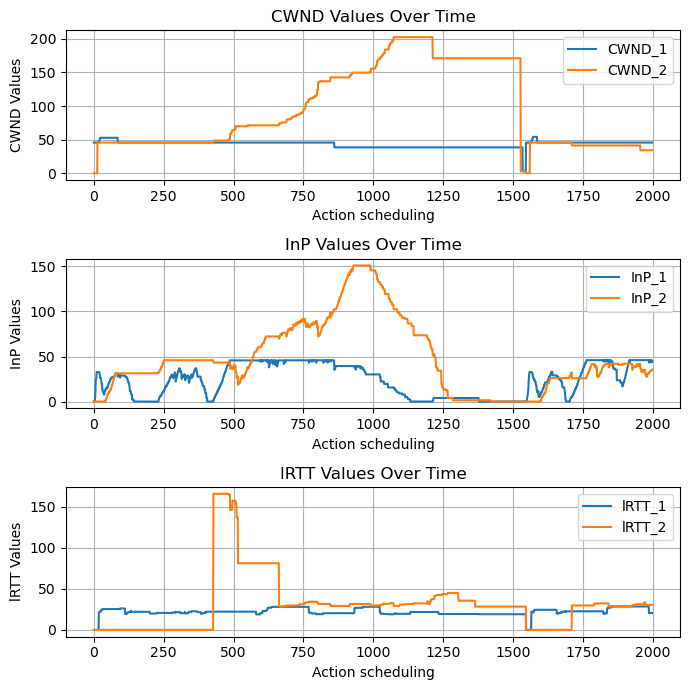

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import islice


file_path = f'../output/{mdl}-{clt}-{size}-0-0.4-{bwd}-{owd}-{var}-{los}-{sch}-state.csv'

# Read the file line by line and manually split the columns
with open(file_path, 'r') as file:
    lines = list(islice(file, 1, 2000))  # Only take lines 100 to 200

# Split each line by comma and create a list of lists
data_list = [line.strip().split(',') for line in lines]

# Convert the list of lists into a DataFrame
data = pd.DataFrame(data_list, columns=['CWND_1', 'InP_1', 'lRTT_1', 'CWND_2', 'InP_2', 'lRTT_2'])

# Convert the columns to numeric, handling any non-numeric issues
data = data.apply(pd.to_numeric, errors='coerce')

# Drop rows with any NaN values to clean the data
data = data.dropna()

# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(7, 7))

# Plot CWND values
axes[0].plot(data.index.to_numpy(), data['CWND_1'].to_numpy(), label='CWND_1')
axes[0].plot(data.index.to_numpy(), data['CWND_2'].to_numpy(), label='CWND_2')
# axes[0].set_xticks([1,1000], [1001,2000])
axes[0].set_xlabel('Action scheduling')
axes[0].set_ylabel('CWND Values')
axes[0].set_title('CWND Values Over Time')
axes[0].legend()
axes[0].grid(True)

# Plot InP values
axes[1].plot(data.index.to_numpy(), data['InP_1'].to_numpy(), label='InP_1')
axes[1].plot(data.index.to_numpy(), data['InP_2'].to_numpy(), label='InP_2')
axes[1].set_xlabel('Action scheduling')
axes[1].set_ylabel('InP Values')
axes[1].set_title('InP Values Over Time')
axes[1].legend()
axes[1].grid(True)

# Plot lRTT values
axes[2].plot(data.index.to_numpy(), data['lRTT_1'].to_numpy(), label='lRTT_1')
axes[2].plot(data.index.to_numpy(), data['lRTT_2'].to_numpy(), label='lRTT_2')
axes[2].set_xlabel('Action scheduling')
axes[2].set_ylabel('lRTT Values')
axes[2].set_title('lRTT Values Over Time')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()


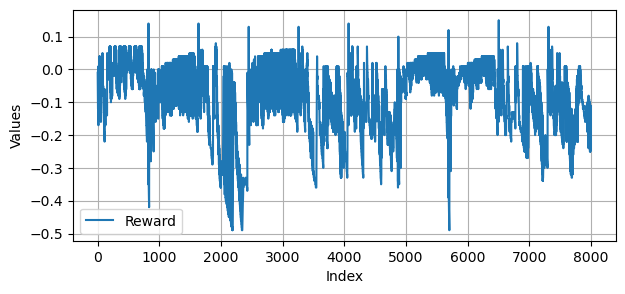

In [19]:
file_path = f'../output/{mdl}-{clt}-{size}-0-0.4-{bwd}-{owd}-{var}-{los}-{sch}-reward.csv'

# Read the file line by line and manually split the columns
with open(file_path, 'r') as file:
    lines = list(islice(file, 1, 8000)) 

# Split each line by comma and create a list of lists
data_list = [line.strip().split(',') for line in lines]

# Convert the list of lists into a DataFrame
data = pd.DataFrame(data_list, columns=['Reward'])

# Convert the columns to numeric, handling any non-numeric issues
data = data.apply(pd.to_numeric, errors='coerce')

# Drop rows with any NaN values to clean the data
data = data.dropna()

# Plot the 6 lines
plt.figure(figsize=(7, 3))

plt.plot(data.index.to_numpy(), data['Reward'].to_numpy(), label='Reward')

plt.xlabel('Index')
plt.ylabel('Values')
# plt.title('R')
plt.legend()
plt.grid(True)
plt.show()


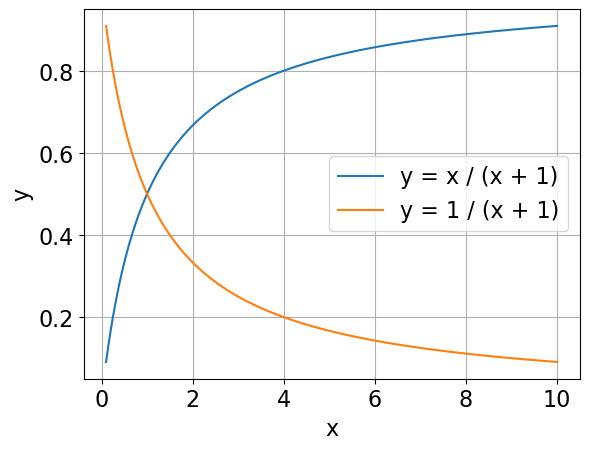

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Define the x values
x = np.linspace(0.1, 10, 400)

# Define the two functions
y1 = x / (x + 1)
y2 = 1 / (x + 1)

plt.rcParams.update({'font.size': 16})

# Plot the functions
plt.plot(x, y1, label="y = x / (x + 1)")
plt.plot(x, y2, label="y = 1 / (x + 1)")

# Add labels and title
plt.xlabel("x")
plt.ylabel("y")
# plt.title("Plot of y = x / (x + 1) and y = 1 / (x + 1)")

# Add a legend
plt.legend()

# Display the plot
plt.grid(True)
plt.show()

